In [1]:
import pandas as pd
import numpy as np
import random
from deap import base, creator, tools, algorithms
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings

# Suppress warnings for cleaner output in Jupyter
warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# PHASE 1: DATA INGESTION & TEMPORAL SPLITTING
# ==========================================
print("Loading and Splitting Datasets...\n")

# Load the raw combined dataset
df_raw = pd.read_excel('./processed_data/combined_data.xlsx')

# --- 1. THE MACRO DATASET (1990 - 2024) ---
# Objective: Maximize rows (long-term trend). 
# Action: Drop plant data (too sparse) and interpolate connectivity.
df_macro = df_raw[df_raw['Year'] >= 1990].reset_index(drop=True)

# Drop plant columns for the Macro model
plant_cols = [col for col in df_macro.columns if 'plant' in col]
df_macro = df_macro.drop(columns=plant_cols)

# Interpolate the connectivity data (which has points in 1990, 1998, 2007)
# Using linear interpolation since it's safer over a 10-year gap than polynomial
df_macro['mean_connectivity_woodland'] = df_macro['mean_connectivity_woodland'].interpolate(method='linear')
df_macro['mean_connectivity_grassland'] = df_macro['mean_connectivity_grassland'].interpolate(method='linear')

# Forward fill to project the 2007 connectivity baseline up to 2024
df_macro = df_macro.ffill().bfill() 

# --- 2. THE MICRO DATASET (2015 - 2024) ---
# Objective: Maximize features (include modern plant abundance data).
df_micro = df_macro[df_macro['Year'] >= 2015].reset_index(drop=True)

# Interpolate/fill any minor gaps in this short window


Loading and Splitting Datasets...



In [3]:
# ==========================================
# PHASE 2: REUSABLE GENETIC ALGORITHM
# ==========================================

# We define the DEAP framework once, globally
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

def run_feature_selection_ga(df, model_name, n_splits=5):
    """
    Runs a Genetic Algorithm to find the optimal feature subset for a given dataframe.
    """
    print(f"=== Starting GA Optimization for: {model_name} ===")
    
    # 1. Isolate Target and Features
    y = df['pollinators_mean_occupancy'].values
    
    # Drop target and irrelevant identifier columns to prevent data leakage
    drop_cols = ['Year', 'pollinators_mean_occupancy', 
                 'pollinating_wild_bees_mean_occupancy', 'pollinating_hoverflies_mean_occupancy']
    
    X_df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    X = X_df.values
    feature_names = X_df.columns.tolist()
    num_features = len(feature_names)
    
    print(f"Initial Features: {num_features} | Rows: {len(df)}")
    
    # 2. Setup DEAP Toolbox for this specific feature space
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, num_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    
    # 3. Define the Fitness Function
    def evaluate(individual):
        selected_indices = [i for i in range(num_features) if individual[i] == 1]
        
        # Severe penalty if the algorithm drops everything
        if len(selected_indices) == 0:
            return (9999.0,)
            
        X_subset = X[:, selected_indices]
        
        # Support Vector Regression Pipeline
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
        ])
        
        # K-Fold Cross Validation 
        # (Use smaller K for the Micro model since it only has 10 rows)
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_subset, y, cv=cv, scoring='neg_mean_squared_error')
        
        rmse = np.sqrt(-scores.mean())
        
        # Dimensionality Penalty: 0.05 added to RMSE for every feature kept
        # This forces the algorithm to eliminate redundant 'All Species' columns
        fitness_score = rmse + (0.05 * len(selected_indices))
        return (fitness_score,)
    
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxUniform, indpb=0.5)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.1) # 10% mutation rate to prevent local optima
    toolbox.register("select", tools.selTournament, tournsize=3)
    # 4. Execute Evolution
    pop = toolbox.population(n=40)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    
    print("Evolving generations...")
    # Run algorithm silently to save console space, capturing just the final result
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=40, 
                        stats=stats, halloffame=hof, verbose=False)
    
    # 5. Output Results
    best_ind = hof[0]
    best_rmse = best_ind.fitness.values[0]
    
    selected_features = [feature_names[i] for i in range(num_features) if best_ind[i] == 1]
    
    print(f"Optimization Complete. Best Fitness Score (RMSE + Penalty): {best_rmse:.4f}")
    print(f"Features Retained ({len(selected_features)}/{num_features}):")
    for feat in selected_features:
        print(f"  - {feat}")
    print("\n")
    
    return selected_features, best_rmse

In [4]:
    

# ==========================================
# PHASE 3: EXECUTE & COMPARE
# ==========================================

# Run the Macro Model (35 years of data, 5-Fold CV)
macro_features, macro_score = run_feature_selection_ga(df_macro, "MACRO MODEL (1990-2024)", n_splits=5)

# Run the Micro Model (10 years of data, 3-Fold CV due to small row count)
micro_features, micro_score = run_feature_selection_ga(df_micro, "MICRO MODEL (2015-2024)", n_splits=3)

print("="*50)
print("FINAL ANALYSIS FOR REPORT:")
print("="*50)
print("If the Micro Model score is significantly lower (better) than the Macro Model,")
print("it indicates that Plant Abundance data is a critical predictor of pollinator health,")
print("justifying the use of short-term, high-dimensional datasets.")

=== Starting GA Optimization for: MACRO MODEL (1990-2024) ===
Initial Features: 13 | Rows: 35
Evolving generations...
Optimization Complete. Best Fitness Score (RMSE + Penalty): 5.2792
Features Retained (2/13):
  - butterfly_connectivity_composite_unsmoothed_index
  - birds_connectivity_composite_unsmoothed_index


=== Starting GA Optimization for: MICRO MODEL (2015-2024) ===
Initial Features: 13 | Rows: 10
Evolving generations...
Optimization Complete. Best Fitness Score (RMSE + Penalty): 1.1032
Features Retained (1/13):
  - butterfly_connectivity_composite_unsmoothed_index


FINAL ANALYSIS FOR REPORT:
If the Micro Model score is significantly lower (better) than the Macro Model,
it indicates that Plant Abundance data is a critical predictor of pollinator health,
justifying the use of short-term, high-dimensional datasets.


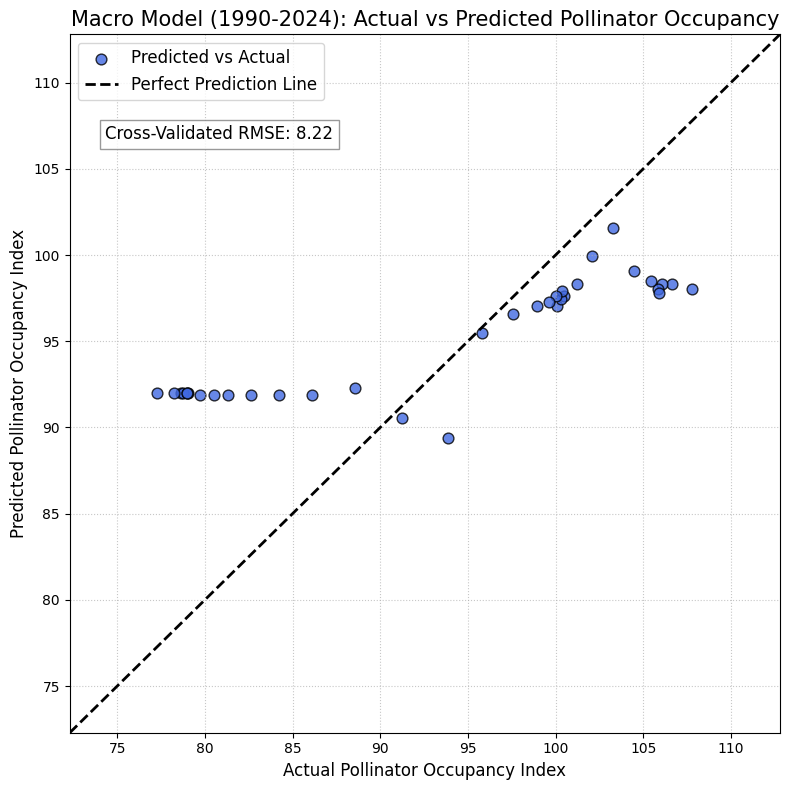

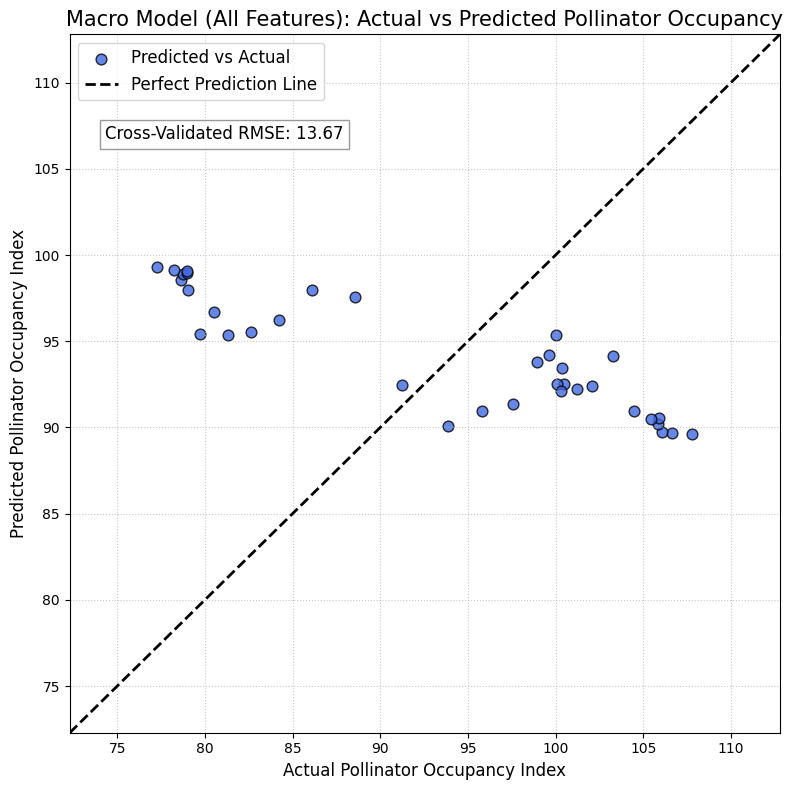

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

def plot_model_results(model, X, y, model_name="Macro Model"):
    """
    Generates a scatter plot of Actual vs. Predicted values to evaluate SVR performance.
    Uses cross-validation predictions to ensure all data points are plotted without data leakage.
    """
    # Generate cross-validated predictions
    # Use 5 splits for Macro (n=35), 3 splits for Micro (n=10)
    cv_splits = 5 if len(y) > 15 else 3
    y_pred = cross_val_predict(model, X, y, cv=cv_splits)
    
    plt.figure(figsize=(8, 8))
    
    # Scatter plot of predictions
    plt.scatter(y, y_pred, alpha=0.8, color='royalblue', edgecolor='k', s=60, label='Predicted vs Actual')
    
    # Plot the "Perfect Prediction" diagonal line
    min_val = min(min(y), min(y_pred)) - 5
    max_val = max(max(y), max(y_pred)) + 5
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction Line')
    
    # Formatting
    plt.title(f'{model_name}: Actual vs Predicted Pollinator Occupancy', fontsize=15)
    plt.xlabel('Actual Pollinator Occupancy Index', fontsize=12)
    plt.ylabel('Predicted Pollinator Occupancy Index', fontsize=12)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Calculate and display RMSE on the plot
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    plt.text(0.05, 0.85, f'Cross-Validated RMSE: {rmse:.2f}', transform=plt.gca().transAxes, 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_").lower()}_results.png', dpi=300)
    plt.show()

model = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
        ])

y = df_macro['pollinators_mean_occupancy'].values
model.fit(df_macro[macro_features], y)  # Fit the model on the optimized feature set from the Macro dataset

model_all = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
        ])
y = df_macro['pollinators_mean_occupancy'].values
model_all.fit(df_macro, y)  # Fit the model on all features


# Example usage (assuming 'macro_model' is your fitted SVR pipeline and 'X_macro_optimized' is your selected feature array):
plot_model_results(model, df_macro[macro_features], y, model_name="Macro Model (1990-2024)")
plot_model_results(model_all, df_macro.drop(columns=['pollinators_mean_occupancy']), y, model_name="Macro Model (All Features)")